In [1]:
#libraries
import os
import torch
import torch.nn as nn
import torch.nn.functional as F
import librosa
import numpy as np
from torch.utils.data import Dataset, DataLoader, WeightedRandomSampler,Subset
from sklearn.metrics import classification_report
from avex import load_model

import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.model_selection import KFold
from sklearn.metrics import (
    f1_score, accuracy_score, roc_auc_score, 
    roc_curve, multilabel_confusion_matrix
)
from tqdm import tqdm

import torchaudio
import torchaudio.transforms as T
import torchaudio.functional as F
import random
import math

import soundfile as sf


c:\Users\anast\miniconda3\envs\bat-naturelm\lib\site-packages\google\api_core\_python_version_support.py:263: FutureWarning: You are using a Python version (3.10.20) which Google will stop supporting in new releases of google.api_core once it reaches its end of life (2026-10-04). Please upgrade to the latest Python version, or at least Python 3.11, to continue receiving updates for google.api_core past that date.
  warnings.warn(message, FutureWarning)
c:\Users\anast\miniconda3\envs\bat-naturelm\lib\site-packages\google\api_core\_python_version_support.py:263: FutureWarning: You are using a Python version (3.10.20) which Google will stop supporting in new releases of google.cloud.storage_control_v2 once it reaches its end of life (2026-10-04). Please upgrade to the latest Python version, or at least Python 3.11, to continue receiving updates for google.cloud.storage_control_v2 past that date.
  warnings.warn(message, FutureWarning)
c:\Users\anast\miniconda3\envs\bat-naturelm\lib\site-p

In [6]:
#Load encoder
effnet_encoder = load_model(
    "esp_aves2_effnetb0_all", 
    device='cpu', 
    return_features_only=True
)
from avex import describe_model
describe_model("esp_aves2_effnetb0_all")

{'name': 'efficientnet',
 'pretrained': False,
 'device': 'cpu',
 'audio_config': {'sample_rate': 16000,
  'n_fft': 800,
  'hop_length': 160,
  'win_length': 800,
  'window': 'hann',
  'n_mels': 128,
  'representation': 'mel_spectrogram',
  'normalize': True,
  'target_length_seconds': 10,
  'window_selection': 'random',
  'center': True,
  'extra_config': None},
 'text_model_name': None,
 'projection_dim': None,
 'temperature': None,
 'eat_cfg': None,
 'extra_config': None,
 'pretraining_mode': None,
 'handle_padding': None,
 'fairseq_weights_path': None,
 'eat_norm_mean': -4.268,
 'eat_norm_std': 4.569,
 'efficientnet_variant': 'b0',
 'use_naturelm': None,
 'fine_tuned': None,
 'language': None,
 'model_id': 'worstchan/EAT-base_epoch30_pretrain',
 '_metadata': {'name': 'esp_aves2_effnetb0_all',
  'model_type': 'efficientnet',
  'pretrained': False,
  'device': 'cpu',
  'has_audio_config': True,
  'has_text_model': False,
  'has_eat_config': False,
  'is_pretraining_mode': None,
  'ha

In [ ]:
class BatAudioPipeline(torch.nn.Module):
    def __init__(self, target_sr=16000, expansion_factor=10, window_sec=10, overlap=0.5):
        super().__init__()
        self.target_sr = target_sr
        self.expansion_factor = expansion_factor
        
        # Windowing parameters
        self.win_samples = window_sec * target_sr
        self.hop_samples = int(self.win_samples * (1.0 - overlap))
        
        # BEATs usually uses 128 Mel bins
        self.mel_spectrogram = T.MelSpectrogram(
            sample_rate=target_sr,
            n_mels=128,
            n_fft=1024,
            hop_length=320 # 20ms frames
        )

    def load_and_expand(self, file_path):
        """Loads audio using soundfile to bypass TorchAudio DLL issues."""
        try:
            # Load using soundfile (returns numpy array and samplerate)
            data, orig_sr = sf.read(file_path)

            # Convert to torch tensor [channels, time]
            # soundfile returns [time, channels] for stereo, so we transpose
            audio = torch.from_numpy(data).float()
            if audio.ndim == 1:
                audio = audio.unsqueeze(0) # Add channel dim for mono
            else:
                audio = audio.transpose(0, 1) # [T, C] -> [C, T]

            # Convert stereo to mono if necessary
            if audio.shape[0] > 1:
                audio = torch.mean(audio, dim=0, keepdim=True)

            # 10x Time Expansion logic
            virtual_sr = orig_sr // self.expansion_factor

            # Resample to 16kHz for NatureLM
            if virtual_sr != self.target_sr:
                audio = F.resample(audio, orig_freq=virtual_sr, new_freq=self.target_sr)

            return audio

        except Exception as e:
            print(f"\n[Warning] Skipping {file_path}: {e}")
            # Return 1 second of silence as a fallback to prevent NoneType errors
            return torch.zeros((1, self.target_sr))

    def apply_bandpass(self, audio):
        """
        Filters frequencies Pipistrelles don't emit.
        In 10x expanded time, a 15kHz real-world high-pass becomes 1.5kHz.
        (The high-cut of 80kHz is already handled by the 16kHz resampling Nyquist limit).
        """
        # Highpass biquad filter at 1.5 kHz (Expanded domain)
        return F.highpass_biquad(audio, sample_rate=self.target_sr, cutoff_freq=15000/self.expansion_factor)

    def generate_colored_noise(self, num_samples, exponent=1.0):
        """0.0=White, 1.0=Pink (Rain), 2.0=Brown (Roar)"""
        white_noise_fft = torch.fft.rfft(torch.randn(num_samples))
        frequencies = torch.fft.rfftfreq(num_samples)
        # Apply power law 1/f^beta
        scaler = 1.0 / (frequencies** (exponent / 2.0) + 1e-10)
        noise = torch.fft.irfft(white_noise_fft * scaler, n=num_samples)
        return (noise / (noise.std() + 1e-10)).unsqueeze(0)
    
    def add_noise_snr(self, audio, noise_audio, snr_db):
        """Mixes background noise at a specific Signal-to-Noise Ratio."""
        # Ensure noise is the same length as the audio
        if noise_audio.shape[1] < audio.shape[1]:
            # Repeat noise if it's too short
            repeats = math.ceil(audio.shape[1] / noise_audio.shape[1])
            noise_audio = noise_audio.repeat(1, repeats)
        
        # Trim noise to exact audio length
        noise_audio = noise_audio[:, :audio.shape[1]]
        
        # Calculate powers
        audio_power = audio.norm(p=2)
        noise_power = noise_audio.norm(p=2)
        
        # Avoid division by zero
        if noise_power == 0:
            return audio
            
        # Calculate required noise scalar to match target SNR
        # SNR = 20 * log10(audio_power / target_noise_power)
        target_noise_power = audio_power / (10 ** (snr_db / 20.0))
        noise_scalar = target_noise_power / noise_power
        
        # Mix
        mixed_audio = audio + (noise_audio * noise_scalar)
        return mixed_audio

    def random_gain(self, audio, min_db=-10, max_db=10):
        """Simulates different microphone sensitivities / distances."""
        gain_db = random.uniform(min_db, max_db)
        # Convert dB to linear scale multiplier
        multiplier = 10 ** (gain_db / 20.0)
        return audio * multiplier

    def window_audio(self, audio):
        """Cuts the 1D audio tensor into overlapping 10s windows."""
        # Unfold creates a view of the tensor in overlapping windows
        # Shape goes from [1, Total_Samples] -> [1, Num_Windows, Window_Samples]
        if audio.shape[1] < self.win_samples:
            # Pad with zeros if the file is shorter than 10 seconds
            pad_amount = self.win_samples - audio.shape[1]
            audio = torch.nn.functional.pad(audio, (0, pad_amount))
            
        windows = audio.unfold(-1, self.win_samples, self.hop_samples)
        # Rearrange to [Num_Windows, 1, Window_Samples] (Batch-like format)
        windows = windows.transpose(0, 1)
        return windows

    #def to_normalized_spectrogram(self, windows):
    #    """Converts raw audio windows to Log-Mel Spectrograms and normalizes."""
    #    # Output shape: [Num_Windows, 1, n_mels, time_frames]
    #    melspec = self.mel_spectrogram(windows)
    #    
    #    # Convert to log scale (adding small epsilon to prevent log(0))
    #    log_melspec = 10.0 * torch.log10(melspec + 1e-10)
    #    
    #    # Instance Normalization (Zero mean, unit variance per window)
    #    # Calculate mean and std over the frequency and time dimensions
    #    mean = log_melspec.mean(dim=[-2, -1], keepdim=True)
    #    std = log_melspec.std(dim=[-2, -1], keepdim=True)
    #    
    #    normalized_spec = (log_melspec - mean) / (std + 1e-8)
    #    
    #    return normalized_spec

    def to_raw_windows(self, windows):
        """NatureLM/BEATs expects raw waveform [Num_Windows, Time]."""
        # windows shape is [Num_Windows, 1, Samples]
        # We remove the channel dimension: [Num_Windows, Samples]
        windows = windows.squeeze(1)

        # Normalize: NatureLM usually expects zero-mean, unit variance raw audio
        mean = windows.mean(dim=-1, keepdim=True)
        std = windows.std(dim=-1, keepdim=True)
        normalized_windows = (windows - mean) / (std + 1e-8)

        #return normalized_windows
        return windows


    def forward(self, file_path, noise_path=None, augment=False):
        """The complete sequence from file path to ML-ready tensor."""
        #0 noise reduce

        # 1. Load & Time Expand
        audio = self.load_and_expand(file_path)
        
        # 2. Bandpass Filter
        audio = self.apply_bandpass(audio)
        
        # 3. Data Augmentation (Only during Training)
        if augment:
            # Random Gain (-12dB to +6dB)
            audio = self.random_gain(audio, min_db=-12.0, max_db=6.0)
            
            # Mix Background Noise
            if random.random() > 0.3: # 70% chance to add noise
                snr = random.uniform(5.0, 25.0)
                # 1. Try to use your File-based noise (e.g., from ASA or Xeno-canto)
                if noise_path and os.path.exists(noise_path) and random.random() > 0.5:
                    try:
                        noise, n_sr = torchaudio.load(noise_path)
                        noise = F.resample(noise, n_sr, self.target_sr)
                        if noise.shape[0] > 1: noise = noise.mean(0, keepdim=True)
    
                        # Match length
                        if noise.shape[1] < audio.shape[1]:
                            noise = noise.repeat(1, (audio.shape[1] // noise.shape[1]) + 1)
                        noise = noise[:, :audio.shape[1]]
    
                        audio = self.add_noise_snr(audio, noise, snr)
                    except:
                        pass # Fallback to synthetic if file fails
                    
                # 2. Use Synthetic Colored Noise (Always available)
                else:
                    # Randomly pick a color: 0=Hiss, 1=Rain/Wind, 2=Deep Rumble
                    beta = random.uniform(0.0, 2.0)
                    noise = self.generate_colored_noise(audio.shape[1], exponent=beta)
                    audio = self.add_noise_snr(audio, noise.to(audio.device), snr)
        
        # 4. Cut into Windows
        windows = self.window_audio(audio)
        
        # 5. Convert to Normalized Spectrogram
        specs = self.to_raw_windows(windows)
        
        return specs

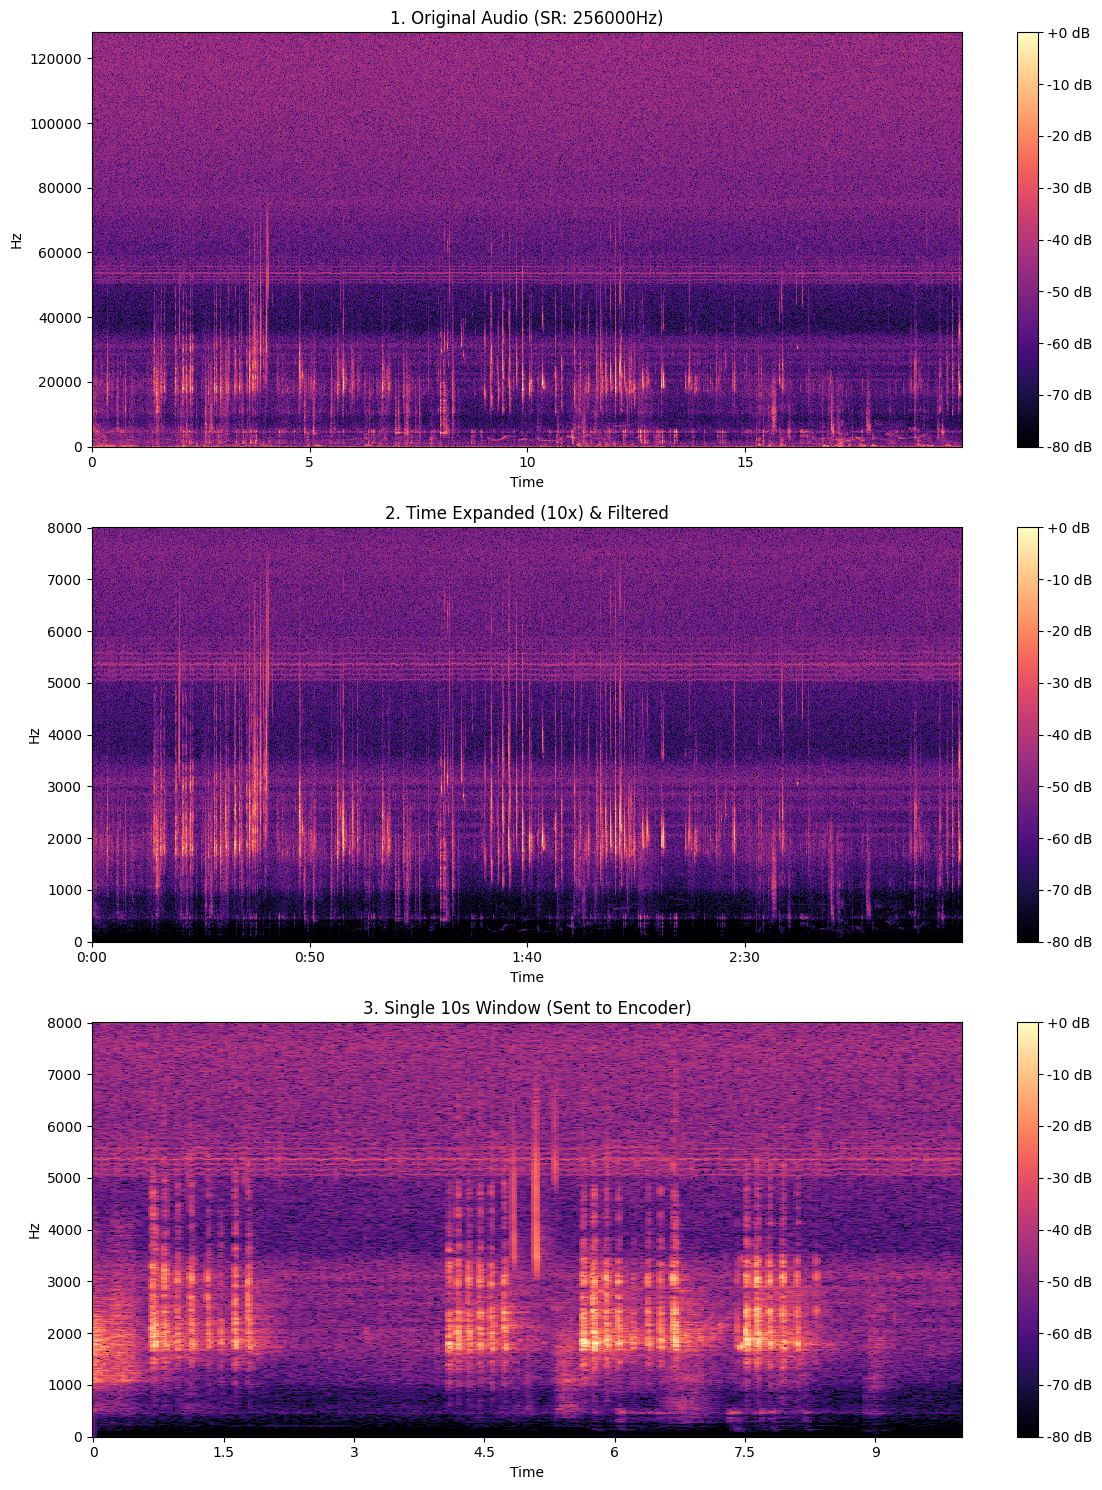

<Figure size 640x480 with 0 Axes>

In [8]:
import matplotlib.pyplot as plt
import librosa.display
import numpy as np
import torch

def visualize_pipeline_steps(pipeline, file_path):
    # 1. LOAD ORIGINAL (No expansion yet)
    data, orig_sr = sf.read(file_path)
    audio_orig = torch.from_numpy(data).float().unsqueeze(0)
    if audio_orig.shape[0] > 1: audio_orig = audio_orig.mean(0, keepdim=True)
    
    # 2. RUN PIPELINE STEP 1: Time Expansion
    audio_expanded = pipeline.load_and_expand(file_path)
    
    # 3. RUN PIPELINE STEP 2: Bandpass
    audio_filtered = pipeline.apply_bandpass(audio_expanded)
    
    # 4. RUN PIPELINE STEP 3: Windowing
    windows = pipeline.window_audio(audio_filtered)
    windows = pipeline.to_raw_windows(windows)  # Convert to raw waveform windows for visualization
    # Grab the first window for visualization
    first_window = windows[3] 

    # --- PLOTTING ---
    fig, axes = plt.subplots(3, 1, figsize=(12, 15))
    
    # Plot 1: Original Ultrasonic Spectrogram
    # ADD .detach().cpu() here
    data_orig = audio_orig.detach().cpu().numpy()[0]
    D_orig = librosa.amplitude_to_db(np.abs(librosa.stft(data_orig)), ref=np.max)
    img1 = librosa.display.specshow(D_orig, sr=orig_sr, x_axis='time', y_axis='linear', ax=axes[0])
    axes[0].set_title(f"1. Original Audio (SR: {orig_sr}Hz)")
    fig.colorbar(img1, ax=axes[0], format="%+2.0f dB")

    # Plot 2: Time-Expanded Spectrogram
    # ADD .detach().cpu() here
    data_exp = audio_filtered.detach().cpu().numpy()[0]
    D_exp = librosa.amplitude_to_db(np.abs(librosa.stft(data_exp)), ref=np.max)
    img2 = librosa.display.specshow(D_exp, sr=pipeline.target_sr, x_axis='time', y_axis='linear', ax=axes[1])
    axes[1].set_title(f"2. Time Expanded ({pipeline.expansion_factor}x) & Filtered")
    fig.colorbar(img2, ax=axes[1], format="%+2.0f dB")

    # Plot 3: A Single 10s Window
    # ADD .detach().cpu() here
    data_win = first_window.detach().cpu().numpy().flatten()
    stft_result = librosa.stft(data_win)
    D_win = librosa.amplitude_to_db(np.abs(stft_result), ref=np.max)
    img3 = librosa.display.specshow(D_win, sr=pipeline.target_sr, x_axis='time', y_axis='linear', ax=axes[2])
    axes[2].set_title(f"3. Single 10s Window (Sent to Encoder)")
    fig.colorbar(img3, ax=axes[2], format="%+2.0f dB")

    plt.tight_layout()
    plt.show()

    plt.tight_layout()
    plt.show()

# To run it:
pipeline = BatAudioPipeline(expansion_factor=10)
visualize_pipeline_steps(pipeline, "C:\\Users\\anast\\Desktop\\College\\BA6\\Bachelor Project\\Source Code\\cnn-call-classifier\\BEATS Linear classifier\\xenocanto-dataset\\type B\\XC913227 - Common Pipistrelle - Pipistrellus pipistrellus.wav")

In [9]:
data, orig_sr = sf.read("C:\\Users\\anast\\Desktop\\College\\BA6\\Bachelor Project\\Source Code\\cnn-call-classifier\\BEATS Linear classifier\\xenocanto-dataset\\type B\\XC913227 - Common Pipistrelle - Pipistrellus pipistrellus.wav")
audio_orig = torch.from_numpy(data).float().unsqueeze(0)
if audio_orig.shape[0] > 1: audio_orig = audio_orig.mean(0, keepdim=True)

# 2. RUN PIPELINE STEP 1: Time Expansion
audio_expanded = pipeline.load_and_expand("C:\\Users\\anast\\Desktop\\College\\BA6\\Bachelor Project\\Source Code\\cnn-call-classifier\\BEATS Linear classifier\\xenocanto-dataset\\type B\\XC913227 - Common Pipistrelle - Pipistrellus pipistrellus.wav")

# 3. RUN PIPELINE STEP 2: Bandpass
audio_filtered = pipeline.apply_bandpass(audio_expanded)

# 4. RUN PIPELINE STEP 3: Windowing
windows = pipeline.window_audio(audio_filtered)
windows = pipeline.to_raw_windows(windows)  # Convert to raw waveform windows for visualization

print(windows.shape)

torch.Size([38, 160000])


In [10]:
class PipistrelleDataset(Dataset):
    def __init__(self, csv_file, root_dir, noise_folder=None, is_training=True):
        self.data = pd.read_csv(csv_file)
        self.root_dir = root_dir
        self.is_training = is_training
        
        # Initialize our processing pipeline
        self.pipeline = BatAudioPipeline(target_sr=16000, expansion_factor=10)
        
        # Pre-load a list of noise files for augmentation
        self.noise_files = []
        if noise_folder and os.path.exists(noise_folder):
            self.noise_files = [os.path.join(noise_folder, f) for f in os.listdir(noise_folder) if f.endswith('.wav')]

    def __len__(self):
        return len(self.data)

    def __getitem__(self, idx):
        row = self.data.iloc[idx]
        file_path = os.path.join(self.root_dir, row['relative_path'])
        
        # Grab a random noise file if we have them
        noise_path = random.choice(self.noise_files) if self.noise_files else None
        
        # Run the entire audio preprocessing and augmentation pipeline
        # Returns shape: [Num_Windows, 1, 128, Frames]
        windows_tensor = self.pipeline(file_path, noise_path=noise_path, augment=self.is_training)
        
        # Extract labels
        labels = torch.tensor([
            row['type_a'], row['type_b'], row['type_c'], 
            row['type_d'], row['echo']
        ], dtype=torch.float32)
        
        return windows_tensor, labels


In [8]:
def build_feature_bank(dataset, encoder, device='cpu'):
    feature_list = []
    label_list = []
    
    encoder.eval()
    with torch.no_grad():
        for i in tqdm(range(len(dataset)), desc="Extracting Features"):
            windows, labels = dataset[i]
            # windows shape: [Num_Windows, 160000]
            
            # Pass through NatureLM
            feats = encoder(windows.to(device))
            if isinstance(feats, dict): feats = feats['x']
            
            # Global Average Pooling: Turn the "Bag" into one 768-dim vector
            # This is the "average fingerprint" of the whole recording
            bag_feature = feats.mean(dim=0).cpu().numpy() 
            
            feature_list.append(bag_feature)
            label_list.append(labels.numpy())
            
    return np.array(feature_list), np.array(label_list)

CSV_PATH = "bat_metadata.csv"
AUDIO_DIR =  "C:\\Users\\anast\\Desktop\\College\\BA6\\Bachelor Project\\Source Code\\cnn-call-classifier\\BEATS Linear classifier\\xenocanto-dataset"
NOISE_DIR = None # Or None if using pure synthetic
full_dataset = PipistrelleDataset(CSV_PATH, AUDIO_DIR, noise_folder=NOISE_DIR, is_training=False)
encoder = load_model(
    "esp_aves2_effnetb0_all", 
    device='cpu', 
    return_features_only=True
)
# X: [N, 768], Y: [N, 5]
X, Y = build_feature_bank(full_dataset, encoder)
np.save("X_features2_not_normalized.npy", X)
np.save("Y_labels2_not_normalized.npy", Y)

Extracting Features: 100%|██████████| 284/284 [10:56<00:00,  2.31s/it]


In [9]:
# Load the files you saved
X_new = np.load("X_features2_not_normalized.npy")
Y_new = np.load("Y_labels2_not_normalized.npy")

print(f"Features Loaded: {X_new.shape}") # Should show [Total_Files, 768]
print(f"Labels Loaded:   {Y_new.shape}") # Should show [Total_Files, 5]

# A quick 'sanity check' - check the first row
print("\nFirst feature vector (first 5 values):", X_new[0][:5])
print("First label row:", Y_new[0])

Features Loaded: (284, 1280, 4, 32)
Labels Loaded:   (284, 5)

First feature vector (first 5 values): [[[ 1.47873625e-01 -5.99659160e-02 -1.21433347e-01 -1.40369669e-01
   -1.51044592e-01 -1.73879698e-01 -1.42317548e-01 -1.45174131e-01
   -1.52493253e-01 -1.99827284e-01 -2.06899494e-01 -2.05183089e-01
   -2.04801053e-01 -1.95181578e-01 -1.79322943e-01 -1.77249178e-01
   -1.90840989e-01 -1.81059048e-01 -1.85959369e-01 -1.71963423e-01
   -1.79457024e-01 -1.60399497e-01 -1.36404291e-01 -1.46437019e-01
   -1.54542297e-01 -1.99519232e-01 -1.94885239e-01 -2.09950909e-01
   -1.79505825e-01 -1.83732271e-01 -1.85743317e-01  1.42761207e+00]
  [ 2.50075430e-01 -1.26183763e-01 -4.54716966e-04 -1.61505312e-01
   -1.61980361e-01 -1.75479144e-01 -1.30403981e-01 -1.32046610e-01
   -1.23892628e-01 -1.61848336e-01 -1.85336515e-01 -1.98909342e-01
   -1.90508276e-01 -1.58294737e-01 -1.67358235e-01 -1.80020407e-01
   -1.81950077e-01 -1.66020304e-01 -1.75785214e-01 -1.81558535e-01
   -1.75617993e-01 -1.7161

In [14]:
def create_composition_labels(y_matrix, label_names):
    comp_labels = []
    for row in y_matrix:
        active = [label_names[i] for i, val in enumerate(row) if val == 1]
        if not active:
            comp_labels.append("Silence/Other")
        else:
            comp_labels.append(" + ".join(active))
    return comp_labels

import matplotlib.colors as mcolors

# 1. Define distinct base colors for your 5 categories
base_colors = {
    'Type A': '#1f77b4', # Blue
    'Type B': '#ff7f0e', # Orange
    'Type C': '#2ca02c', # Green
    'Type D': '#d62728', # Red
    'Echo':   '#9467bd'  # Purple
}

def mix_multi_labels(row, label_names, base_colors):
    """
    Finds all active labels in a row and averages their RGB colors.
    """
    active_indices = [i for i, val in enumerate(row) if val == 1]
    
    if not active_indices:
        return mcolors.to_rgb('#e0e0e0') # Light grey for unlabeled/silence
    
    # Get RGB tuples for all active labels
    rgbs = [mcolors.to_rgb(base_colors[label_names[i]]) for i in active_indices]
    
    # Average the RGB values
    mixed_rgb = np.mean(rgbs, axis=0)
    return mixed_rgb

Running PCA...
Running UMAP...
Running t-SNE...


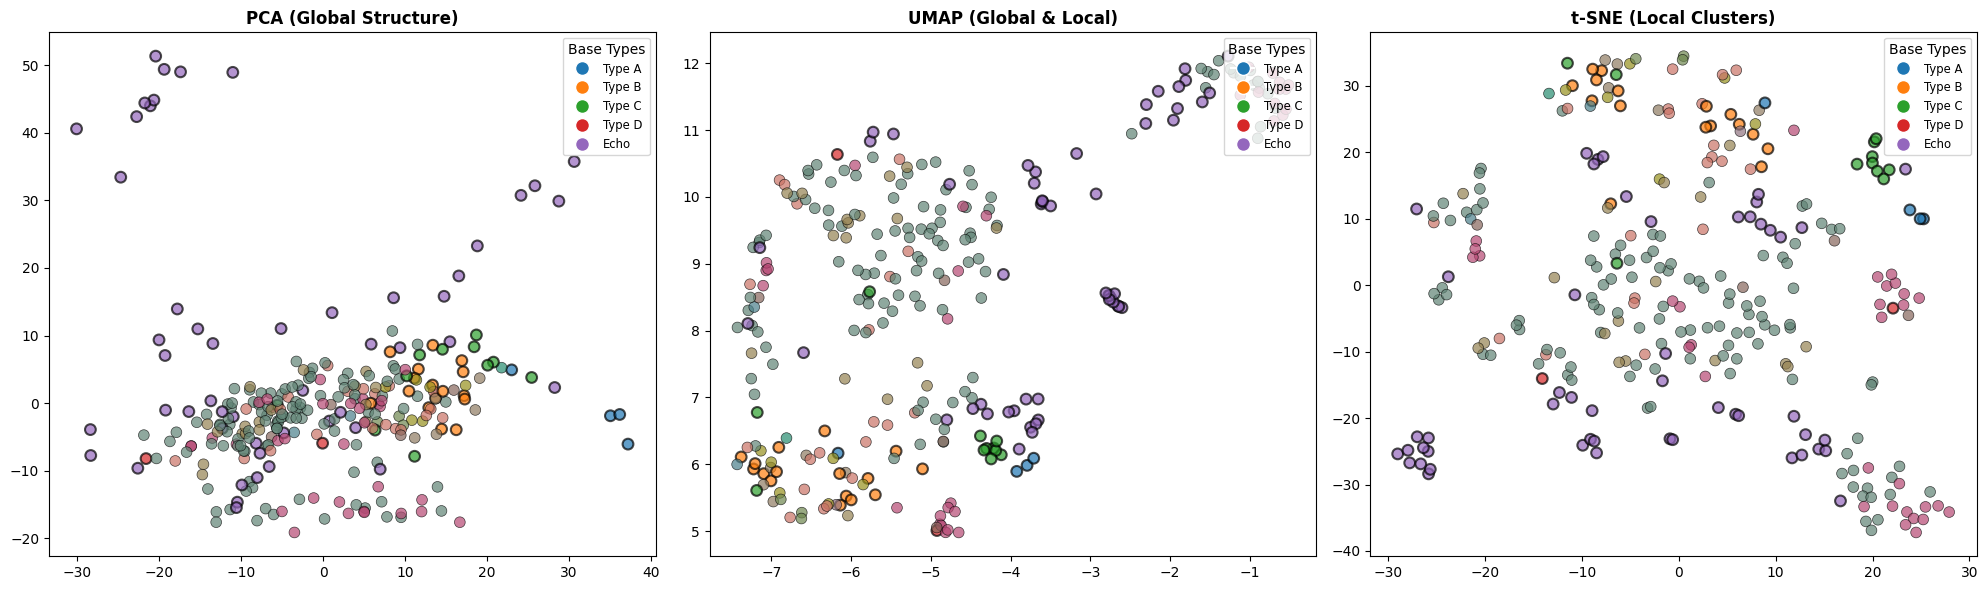

In [24]:
from sklearn.preprocessing import StandardScaler
from sklearn.decomposition import PCA
from sklearn.manifold import TSNE
from matplotlib.lines import Line2D
import umap

# 1. Load Data
X = np.load("X_features2_not_normalized.npy")
y = np.load("Y_labels2_not_normalized.npy")

# --- Label Prep ---
# Create a single 'Class' label for coloring. 
# We'll pick the first active 'Type' column, or 'None' if all 0.
#label_names = ['Type A', 'Type B', 'Type C', 'Type D', 'Echo']
#def get_primary_label(row):
#    for i, val in enumerate(row):
#        if val == 1: return label_names[i]
#    return 'Other/Silence'
#
#color_labels = [get_primary_label(row) for row in y]

# Usage
label_names = ['A', 'B', 'C', 'D', 'Echo']
color_labels = create_composition_labels(y, label_names)
# Generate the color array for your data
label_names = ['Type A', 'Type B', 'Type C', 'Type D', 'Echo']
point_colors = [mix_multi_labels(row, label_names, base_colors) for row in y]

# Now use 'color_labels' in the sns.scatterplot(hue=color_labels) 
# code from the previous step.

# 2. Preprocessing (Standard Scaling is CRITICAL)
#  Average the windows and Scale the data
X_2d_max = np.max(X, axis=(3,2)) if X.ndim == 4 else X
X_scaled_max = StandardScaler().fit_transform(X_2d_max )

X_2d_mean = np.mean(X, axis=(3,2)) if X.ndim == 4 else X
X_scaled = StandardScaler().fit_transform(X_2d_mean)


# 3. Apply Dimensionality Reduction
print("Running PCA...")
pca_res = PCA(n_components=2).fit_transform(X_scaled)

print("Running UMAP...")
umap_res = umap.UMAP(n_neighbors=40, min_dist=0.1, metric='cosine').fit_transform(X_scaled)

print("Running t-SNE...")
tsne_res = TSNE(n_components=2, perplexity=15, init='pca', learning_rate='auto').fit_transform(X_scaled)

# 4. Visualization
fig, axes = plt.subplots(1, 3, figsize=(20, 6))
titles = ['PCA (Global Structure)', 'UMAP (Global & Local)', 't-SNE (Local Clusters)']
results = [pca_res, umap_res, tsne_res]

for i, res in enumerate(results):
    ax = axes[i]
    
    
    edge_widths = [1.5 if row.sum() == 1 else 0.5 for row in y]
    
    # Use ax.scatter instead of sns.scatterplot
    # This allows us to pass our mixed 'point_colors' directly to 'c'
    ax.scatter(
        res[:, 0], res[:, 1], 
        c=point_colors, 
        s=60, alpha=0.7, 
        edgecolor='black', 
        linewidth=edge_widths
    )
    
    ax.set_title(titles[i], fontweight='bold')
    
    # Since we aren't using Seaborn's auto-legend, we add a manual one
    # using the base_colors dictionary we defined earlier
    legend_elements = [
        Line2D([0], [0], marker='o', color='w', label=k,
               markerfacecolor=v, markersize=10) 
        for k, v in base_colors.items()
    ]
    ax.legend(handles=legend_elements, title="Base Types", loc='upper right', fontsize='small')

plt.tight_layout()
plt.show()


UNIQUE LABEL COMBINATION CLUSTERING METRICS
              silhouette  davies_bouldin  calinski_harabasz  purity
encoder                                                            
effnetb0-all     -0.1576          3.3555             3.7478  0.4468

ONE-vs-REST CLUSTERING METRICS  (per call type)

  Encoder: effnetb0-all
        silhouette  davies_bouldin  calinski_harabasz
label                                                
Type A     -0.0192          3.2723             3.2061
Type B     -0.0732          4.5103             5.3314
Type C      0.0614          4.4513            10.0276
Type D     -0.0570          4.8804             3.1185
Echo       -0.0292          3.5021             7.1762


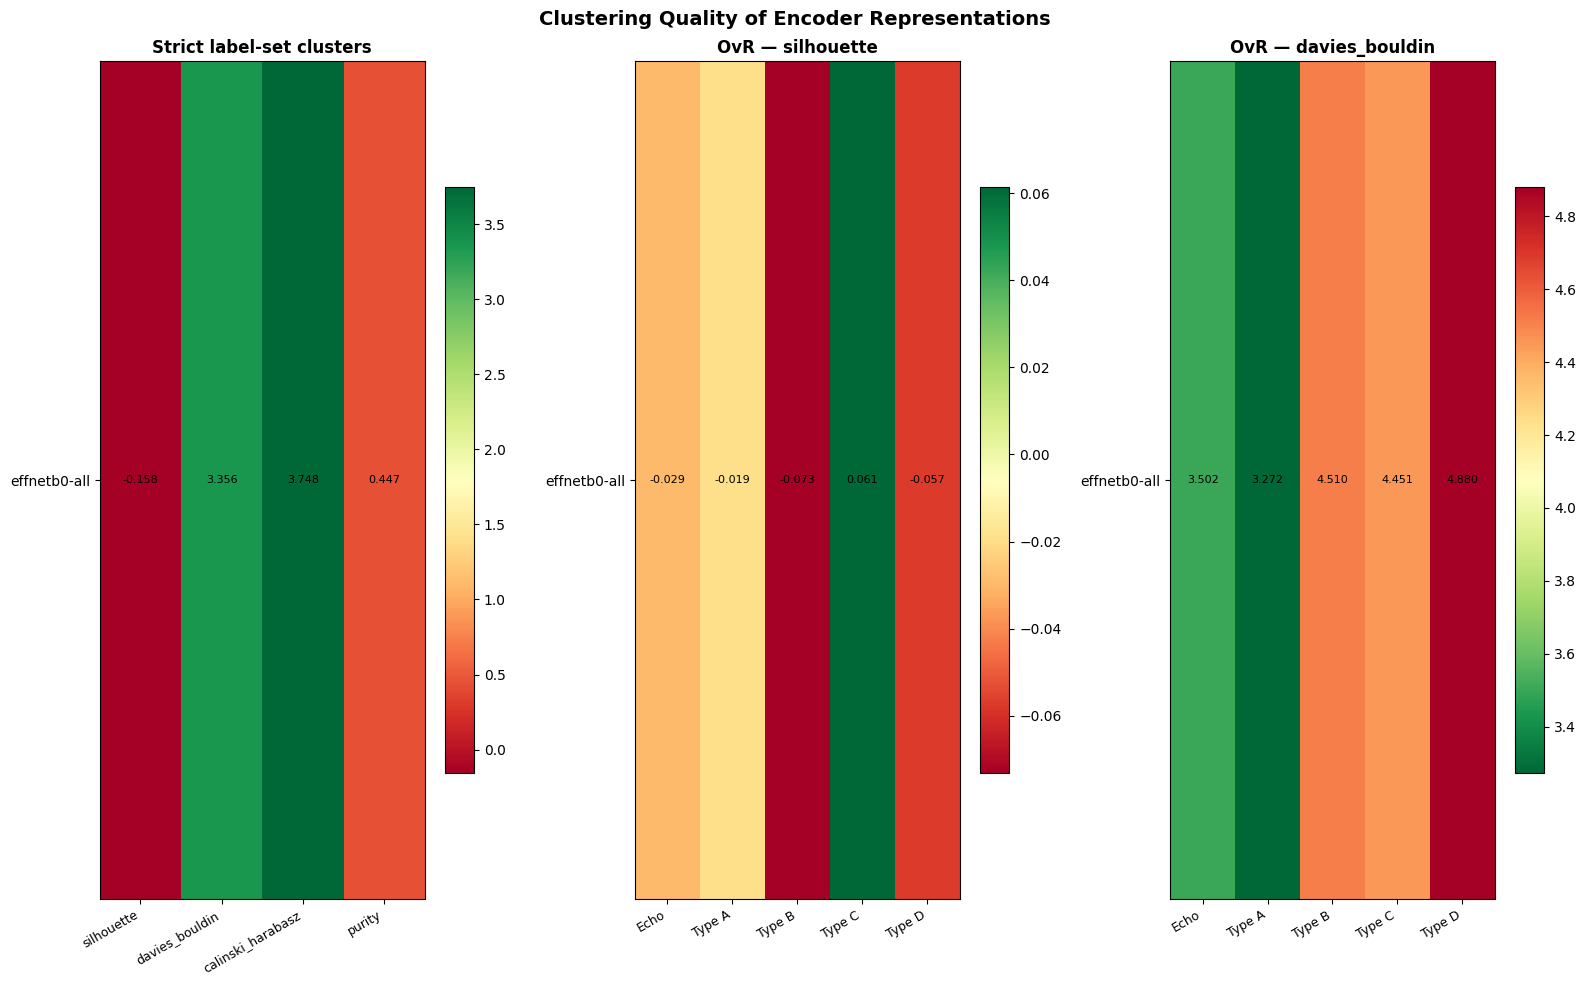

In [ ]:
import numpy as np
from sklearn.metrics import silhouette_score, davies_bouldin_score, calinski_harabasz_score, adjusted_rand_score
from sklearn.preprocessing import LabelEncoder
from itertools import combinations

# ── helpers ──────────────────────────────────────────────────────────────────

def cluster_purity(embeddings_2d, string_labels):
    """
    Purity: for each unique label-set cluster, what fraction of its
    nearest-cluster members share the majority label?
    Here we use the label assignments themselves as 'clusters'.
    """
    le = LabelEncoder()
    int_labels = le.fit_transform(string_labels)
    unique = np.unique(int_labels)
    total = 0
    for cl in unique:
        mask = int_labels == cl
        # majority label within this cluster is itself (pure by definition
        # for composition labels), so purity = fraction of dataset in
        # pure clusters — useful when compared across encoders.
        total += mask.sum()
    # True inter-cluster purity requires a predicted clustering;
    # here we expose per-label cohesion via silhouette instead.
    # This function computes *overall purity* of a k-means fit for comparison.
    from sklearn.cluster import KMeans
    k = len(unique)
    km = KMeans(n_clusters=k, n_init=10, random_state=42).fit(embeddings_2d)
    pred = km.labels_
    purity = 0.0
    for cl in np.unique(pred):
        mask = pred == cl
        true_in_cluster = int_labels[mask]
        counts = np.bincount(true_in_cluster, minlength=len(unique))
        purity += counts.max()
    return purity / len(int_labels)


def compute_strict_metrics(embedding, comp_labels):
    """
    Treat every unique label-combination as its own cluster.
    Requires at least 2 distinct labels and >=2 samples per label.
    """
    le = LabelEncoder()
    int_labels = le.fit_transform(comp_labels)

    # Drop clusters with only 1 sample (metrics undefined for singletons)
    counts = np.bincount(int_labels)
    valid_mask = np.isin(int_labels, np.where(counts >= 2)[0])
    emb_v = embedding[valid_mask]
    lbl_v = int_labels[valid_mask]

    n_clusters = len(np.unique(lbl_v))
    if n_clusters < 2:
        return {k: np.nan for k in
                ["silhouette", "davies_bouldin", "calinski_harabasz", "purity"]}

    return {
        "silhouette":          silhouette_score(emb_v, lbl_v, metric="euclidean"),
        "davies_bouldin":      davies_bouldin_score(emb_v, lbl_v),
        "calinski_harabasz":   calinski_harabasz_score(emb_v, lbl_v),
        "purity":              cluster_purity(emb_v,
                                   np.array(comp_labels)[valid_mask]),
    }


def compute_ovr_metrics(embedding, y_matrix, label_names):
    """
    One-vs-Rest: for each call type, treat positive samples as cluster 1
    and negatives as cluster 0.  Returns a dict-of-dicts keyed by label name.
    """
    results = {}
    for i, name in enumerate(label_names):
        binary = y_matrix[:, i].astype(int)
        n_pos = binary.sum()
        n_neg = (binary == 0).sum()

        if n_pos < 2 or n_neg < 2:          # not enough samples
            results[name] = {k: np.nan for k in
                             ["silhouette", "davies_bouldin",
                              "calinski_harabasz"]}
            continue

        results[name] = {
            "silhouette":        silhouette_score(embedding, binary,
                                                  metric="euclidean"),
            "davies_bouldin":    davies_bouldin_score(embedding, binary),
            "calinski_harabasz": calinski_harabasz_score(embedding, binary),
        }
    return results


def compute_all_metrics(embedding_dict, y_matrix, label_names):
    """
    Run both metric sets for every named embedding.

    Parameters
    ----------
    embedding_dict : dict  e.g. {"PCA": pca_res, "UMAP": umap_res, ...}
    y_matrix       : (N, C) binary numpy array
    label_names    : list of C strings

    Returns
    -------
    strict_df : pd.DataFrame  — one row per encoder
    ovr_df    : pd.DataFrame  — one row per (encoder × label)
    """
    import pandas as pd

    comp_labels = create_composition_labels(y_matrix, label_names)

    strict_rows, ovr_rows = [], []

    for enc_name, emb in embedding_dict.items():
        # ── strict ──
        s = compute_strict_metrics(emb, comp_labels)
        strict_rows.append({"encoder": enc_name, **s})

        # ── one-vs-rest ──
        ovr = compute_ovr_metrics(emb, y_matrix, label_names)
        for lbl, metrics in ovr.items():
            ovr_rows.append({"encoder": enc_name, "label": lbl, **metrics})

    strict_df = pd.DataFrame(strict_rows).set_index("encoder")
    ovr_df    = pd.DataFrame(ovr_rows)

    return strict_df, ovr_df


# ── pretty-print / plot helper ────────────────────────────────────────────────

def print_metric_tables(strict_df, ovr_df):
    import pandas as pd
    pd.set_option("display.float_format", "{:.4f}".format)

    print("\n" + "="*60)
    print("UNIQUE LABEL COMBINATION CLUSTERING METRICS")
    print("="*60)
    print(strict_df.to_string())

    print("\n" + "="*60)
    print("ONE-vs-REST CLUSTERING METRICS  (per call type)")
    print("="*60)
    for enc in ovr_df["encoder"].unique():
        sub = ovr_df[ovr_df["encoder"] == enc].set_index("label")
        print(f"\n  Encoder: {enc}")
        print(sub[["silhouette", "davies_bouldin",
                   "calinski_harabasz"]].to_string())


def plot_metric_heatmaps(strict_df, ovr_df, figsize=(16, 10)):
    """Heatmap summary — easy to drop into a thesis/presentation."""
    import pandas as pd

    fig, axes = plt.subplots(1, 3, figsize=figsize)
    fig.suptitle("Clustering Quality of Encoder Representations",
                 fontsize=14, fontweight="bold")

    metrics_strict = ["silhouette", "davies_bouldin",
                      "calinski_harabasz", "purity"]

    # ── left: strict metrics ──
    ax = axes[0]
    data = strict_df[metrics_strict].astype(float)
    im = ax.imshow(data.values, aspect="auto", cmap="RdYlGn")
    ax.set_xticks(range(len(metrics_strict)))
    ax.set_xticklabels(metrics_strict, rotation=30, ha="right", fontsize=9)
    ax.set_yticks(range(len(data)))
    ax.set_yticklabels(data.index)
    ax.set_title("Strict label-set clusters", fontweight="bold")
    for r in range(data.shape[0]):
        for c in range(data.shape[1]):
            ax.text(c, r, f"{data.values[r, c]:.3f}",
                    ha="center", va="center", fontsize=8)
    plt.colorbar(im, ax=ax, shrink=0.7)

    # ── centre & right: OvR silhouette and DB per encoder ──
    for ax_idx, metric in enumerate(["silhouette", "davies_bouldin"], start=1):
        ax = axes[ax_idx]
        pivot = ovr_df.pivot(index="encoder", columns="label",
                             values=metric).astype(float)
        cmap = "RdYlGn" if metric == "silhouette" else "RdYlGn_r"
        im = ax.imshow(pivot.values, aspect="auto", cmap=cmap)
        ax.set_xticks(range(pivot.shape[1]))
        ax.set_xticklabels(pivot.columns, rotation=30, ha="right", fontsize=9)
        ax.set_yticks(range(pivot.shape[0]))
        ax.set_yticklabels(pivot.index)
        ax.set_title(f"OvR — {metric}", fontweight="bold")
        for r in range(pivot.shape[0]):
            for c in range(pivot.shape[1]):
                ax.text(c, r, f"{pivot.values[r, c]:.3f}",
                        ha="center", va="center", fontsize=8)
        plt.colorbar(im, ax=ax, shrink=0.7)

    plt.tight_layout()
    plt.show()


# ── usage ─────────────────────────────────────────────────────────────────────

label_names = ['Type A', 'Type B', 'Type C', 'Type D', 'Echo']

# Use the full-dimensional scaled embedding, NOT the 2D projections
#embedding_dict = {
#    "effnetb0-all": X_scaled,   # add other encoders here when comparing
#}

embedding_dict = {
    #"PCA":   pca_res,
    #"UMAP":  umap_res,
    #"t-SNE": tsne_res,
     "effnetb0-all mean": X_scaled,
     "effnetb0-all max": X_scaled_max,
}

strict_df, ovr_df = compute_all_metrics(embedding_dict, y, label_names)
print_metric_tables(strict_df, ovr_df)
plot_metric_heatmaps(strict_df, ovr_df)

In [15]:
import torch
import torch.nn as nn
import torch.optim as optim
import numpy as np
from sklearn.model_selection import KFold
from sklearn.metrics import accuracy_score, f1_score

# 1. Define the Architecture again
class BatProbe(nn.Module):
    def __init__(self, input_dim=1280, output_dim=5):
        super(BatProbe, self).__init__()
        
        # This layer will turn (1280, 4, 32) into (1280, 1, 1) regardless of input size
        self.pool = nn.AdaptiveAvgPool2d((1, 1))
        
        self.network = nn.Sequential(
            nn.Linear(input_dim, 256),
            nn.ReLU(),
            nn.Dropout(0.3),
            nn.Linear(256, output_dim),
            nn.Sigmoid()
        )

    def forward(self, x):
        # Check if the input is 4D (Batch, Channels, Height, Width)
        if x.dim() == 4:
            # 1. Reduce (4, 32) spatial dimensions to (1, 1)
            x = self.pool(x) 
            # 2. Flatten to (Batch, 1280)
            x = x.view(x.size(0), -1)
            
        return self.network(x)

# 1. LOAD THE DATA
# This brings back your 1280-dim features and your binary labels
X = np.load("X_features2_not_normalized.npy")
y = np.load("Y_labels2_not_normalized.npy")
label_names = ['Type A', 'Type B', 'Type C', 'Type D', 'Echo']

# 2. Setup CV parameters
kf = KFold(n_splits=5, shuffle=True, random_state=42)
fold_accuracies = []
fold_f1s = []

print(f"Starting 5-Fold CV for Neural Probe...\n")

# 3. Cross-Validation Loop
for fold, (train_idx, val_idx) in enumerate(kf.split(X)):
    # Create Fold Data
    X_train_f, X_val_f = X[train_idx], X[val_idx]
    y_train_f, y_val_f = y[train_idx], y[val_idx]
    
    # Scale within the fold (to avoid data leakage)
    scaler = StandardScaler()
    X_train_f2d = np.mean(X_train_f, axis=(3,2)) if X_train_f.ndim == 4 else X_train_f
    X_val_f2d = np.mean(X_val_f, axis=(3,2))
    X_train_f = torch.FloatTensor(scaler.fit_transform(X_train_f2d))
    X_val_f = torch.FloatTensor(scaler.transform(X_val_f2d))
    y_train_f = torch.FloatTensor(y_train_f)
    
    # Initialize Model, Loss, Optimizer for THIS fold
    probe = BatProbe()
    criterion = nn.BCELoss()
    optimizer = optim.Adam(probe.parameters(), lr=0.001)
    
    # Simple Training Loop for the fold
    probe.train()
    for epoch in range(50):
        optimizer.zero_grad()
        outputs = probe(X_train_f)
        loss = criterion(outputs, y_train_f)
        loss.backward()
        optimizer.step()
    
    # Evaluate on the validation fold
    probe.eval()
    with torch.no_grad():
        val_outputs = probe(X_val_f)
        preds = (val_outputs > 0.5).int().numpy()
        
    # Calculate metrics
    acc = accuracy_score(y_val_f, preds)
    f1 = f1_score(y_val_f, preds, average='macro')
    
    fold_accuracies.append(acc)
    fold_f1s.append(f1)
    print(f"Fold {fold+1}: Accuracy = {acc:.2%}, F1 = {f1:.4f}")

    # Print confusion matrix for this fold
    cm = multilabel_confusion_matrix(y_val_f, preds)
    print(f"Confusion Matrices for Fold {fold+1}:")
    for i, label in enumerate(label_names):
        print(f"  {label}:\n{cm[i]}\n")
        

# 4. Final Summary
print("\n" + "="*30)
print("   NN PROBE CV SUMMARY")
print("="*30)
print(f"Mean Subset Accuracy: {np.mean(fold_accuracies):.2%} (+/- {np.std(fold_accuracies):.2%})")
print(f"Mean Micro F1:        {np.mean(fold_f1s):.4f}")


Starting 5-Fold CV for Neural Probe...

Fold 1: Accuracy = 68.42%, F1 = 0.7645
Confusion Matrices for Fold 1:
  Type A:
[[53  1]
 [ 2  1]]

  Type B:
[[43  1]
 [ 4  9]]

  Type C:
[[19  6]
 [ 4 28]]

  Type D:
[[47  0]
 [ 3  7]]

  Echo:
[[ 9  2]
 [ 1 45]]

Fold 2: Accuracy = 70.18%, F1 = 0.7280
Confusion Matrices for Fold 2:
  Type A:
[[53  0]
 [ 3  1]]

  Type B:
[[43  4]
 [ 0 10]]

  Type C:
[[23  5]
 [ 3 26]]

  Type D:
[[50  0]
 [ 4  3]]

  Echo:
[[ 4  1]
 [ 5 47]]

Fold 3: Accuracy = 68.42%, F1 = 0.8197
Confusion Matrices for Fold 3:
  Type A:
[[54  0]
 [ 2  1]]

  Type B:
[[34  4]
 [ 5 14]]

  Type C:
[[23  5]
 [ 2 27]]

  Type D:
[[51  0]
 [ 0  6]]

  Echo:
[[ 9  0]
 [ 4 44]]

Fold 4: Accuracy = 68.42%, F1 = 0.8287
Confusion Matrices for Fold 4:
  Type A:
[[54  0]
 [ 1  2]]

  Type B:
[[39  1]
 [ 6 11]]

  Type C:
[[17  5]
 [ 5 30]]

  Type D:
[[52  1]
 [ 1  3]]

  Echo:
[[11  2]
 [ 0 44]]

Fold 5: Accuracy = 75.00%, F1 = 0.8177
Confusion Matrices for Fold 5:
  Type A:
[[53  0]

In [20]:
import torch
import torch.nn as nn
import torch.optim as optim
import numpy as np
from torch.utils.data import Dataset, DataLoader
from sklearn.model_selection import KFold

# 1. THE AUGMENTER CLASS
class FeatureAugmenter:
    def __init__(self, noise_level=0.05, gain_range=(0.8, 1.2)):
        self.noise_level = noise_level
        self.gain_range = gain_range

    def apply(self, x, y):
        # A. Random Gain (Scaling)
        gain = np.random.uniform(self.gain_range[0], self.gain_range[1])
        x = x * gain
        
        # B. Additive White Noise
        noise = torch.randn_like(x) * self.noise_level
        x = x + noise
        
        # C. Simple Mixup (50% chance)
        # Blends this sample with a random version of itself/another sample
        if np.random.random() > 0.5:
            # For simplicity, we just jitter the features slightly
            x = x * 0.9 + (torch.randn_like(x) * 0.1)
            
        return x, y

# 2. AUGMENTED DATASET
class AugmentedBatDataset(Dataset):
    def __init__(self, features, labels, augment=False):
        self.features = torch.FloatTensor(features)
        self.labels = torch.FloatTensor(labels)
        self.augment = augment
        self.augmenter = FeatureAugmenter()

    def __len__(self):
        return len(self.features)

    def __getitem__(self, idx):
        x = self.features[idx]
        y = self.labels[idx]
        
        if self.augment:
            x, y = self.augmenter.apply(x, y)
            
        return x, y

# 3. TRAINING LOOP WITH K-FOLD
X = np.load("X_features2.npy") # The pooled (284, 1280) features
y = np.load("Y_labels2.npy")
kf = KFold(n_splits=5, shuffle=True, random_state=42)

for fold, (train_idx, val_idx) in enumerate(kf.split(X)):
    # Create Datasets
    train_ds = AugmentedBatDataset(X[train_idx], y[train_idx], augment=True)
    val_ds = AugmentedBatDataset(X[val_idx], y[val_idx], augment=False)
    
    train_loader = DataLoader(train_ds, batch_size=32, shuffle=True)
    val_loader = DataLoader(val_ds, batch_size=32)

    # Initialize Model (BatProbe from previous steps)
    model = BatProbe(input_dim=1280)
    optimizer = optim.Adam(model.parameters(), lr=0.001)
    criterion = nn.BCELoss()

    print(f"\nTraining Fold {fold+1}...")
    for epoch in range(100): # More epochs because augmentation makes it harder to learn
        model.train()
        for batch_x, batch_y in train_loader:
            optimizer.zero_grad()
            outputs = model(batch_x)
            loss = criterion(outputs, batch_y)
            loss.backward()
            optimizer.step()
            
    # Evaluation (Aggregate for the final Confusion Matrix)
    # ... [Insert your Evaluation/Confusion Matrix logic here] ...


Training Fold 1...

Training Fold 2...

Training Fold 3...

Training Fold 4...

Training Fold 5...
